In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.stats
import pandas as pd
import pyfish

In [3]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 30}

plt.rc('font', **font)

In [4]:
with open('correlation_data_export.pkl','rb') as file:
    df = pd.read_pickle('correlation_data_export.pkl')

In [6]:
freq_timeseries = np.loadtxt('covid_data/covid_freq_timeseries_T300.csv',delimiter=',')
covid_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('yeast_data/ypd_freq_timeseries_T99.csv',delimiter=',')
ypd_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('yeast_data/ypa_freq_timeseries_T110.csv',delimiter=',')
ypa_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('mnv_data/mnv_ab_freq_timeseries.csv',delimiter=',')
mnv_ab_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('mnv_data/mnv_no_ab_freq_timeseries.csv',delimiter=',')
mnv_no_ab_ts = freq_timeseries.T


with open('covid_data/covid_processed_T300.pkl','rb') as file:
    covid_data = pickle.load(file)

with open('yeast_data/ypd_processed_T99.pkl','rb') as file:
    ypd_data = pickle.load(file)

with open('yeast_data/ypa_processed_T110.pkl','rb') as file:
    ypa_data = pickle.load(file)

with open('mnv_data/mnv_ab_processed.pkl','rb') as file:
    mnv_ab_data = pickle.load(file)

with open('mnv_data/mnv_no_ab_processed.pkl','rb') as file:
    mnv_no_ab_data = pickle.load(file)

# main figure 1 

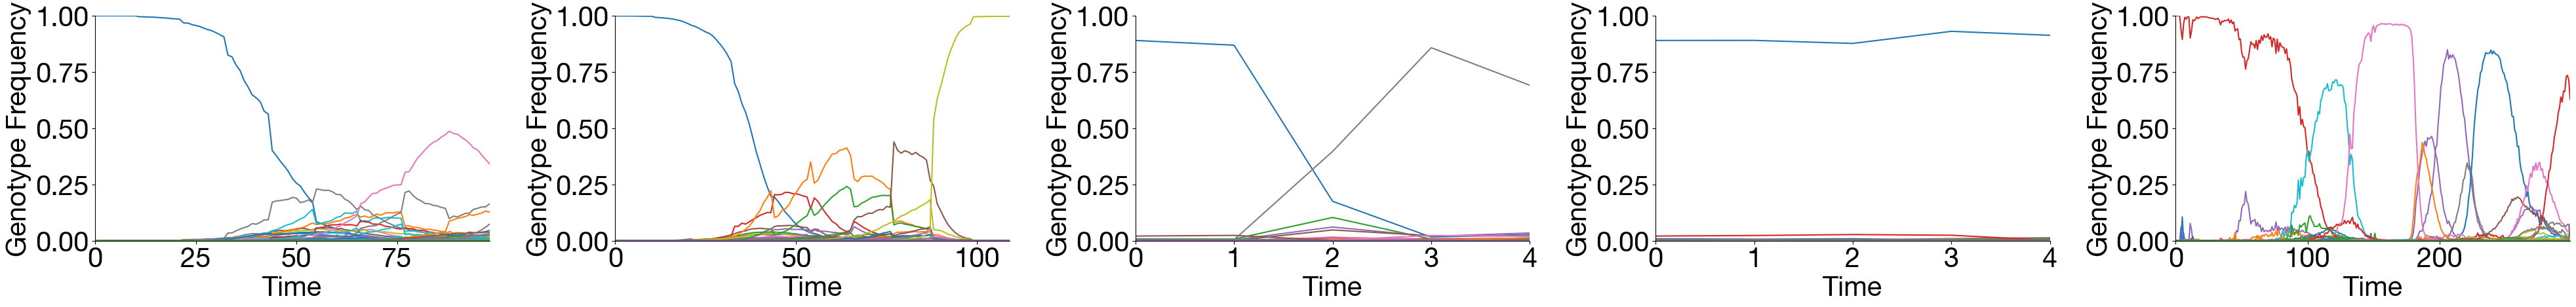

In [12]:
high_rare_cutoff = 10**(-3.5)
ypd_high_rare_cutoff = 10**(-3)
ypa_high_rare_cutoff = 10**(-3)

low_rare_cutoff = 10**(-5)
fig, axs = plt.subplots(1,5,figsize=(40,5.4))
plt.tight_layout()

# [Panel A] first row
axs[0].plot(ypd_ts)
axs[0].set_xlim(0,ypd_ts.shape[0]-1)
axs[0].set_ylim(0,1)
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Genotype Frequency')
axs[0].spines[['right', 'top']].set_visible(False)
# axs[0].set_title('Wright-Fisher',fontsize=30)

axs[1].plot(ypa_ts)
axs[1].set_xlim(0,ypa_ts.shape[0]-1)
axs[1].set_ylim(0,1)
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Genotype Frequency')
axs[1].spines[['right', 'top']].set_visible(False)
# axs[1].set_title('Moran',fontsize=30)

# [Panel A] first row
axs[2].plot(mnv_ab_ts)
axs[2].set_xlim(0,mnv_ab_ts.shape[0]-1)
axs[2].set_ylim(0,1)
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Genotype Frequency')
axs[2].spines[['right', 'top']].set_visible(False)
# axs[0].set_title('Wright-Fisher',fontsize=30)

axs[3].plot(mnv_no_ab_ts)
axs[3].set_xlim(0,mnv_no_ab_ts.shape[0]-1)
axs[3].set_ylim(0,1)
axs[3].set_xlabel('Time')
axs[3].set_ylabel('Genotype Frequency')
axs[3].spines[['right', 'top']].set_visible(False)
# axs[1].set_title('Moran',fontsize=30)

axs[4].plot(covid_ts)
axs[4].set_xlim(0,covid_ts.shape[0]-1)
axs[4].set_ylim(0,1)
axs[4].set_xlabel('Time')
axs[4].set_ylabel('Genotype Frequency')
axs[4].spines[['right', 'top']].set_visible(False)
# axs[2].set_title('Serial Dilution/Chemostat',fontsize=30)

plt.tight_layout()
plt.savefig('paper_plots/exp_traj.pdf')

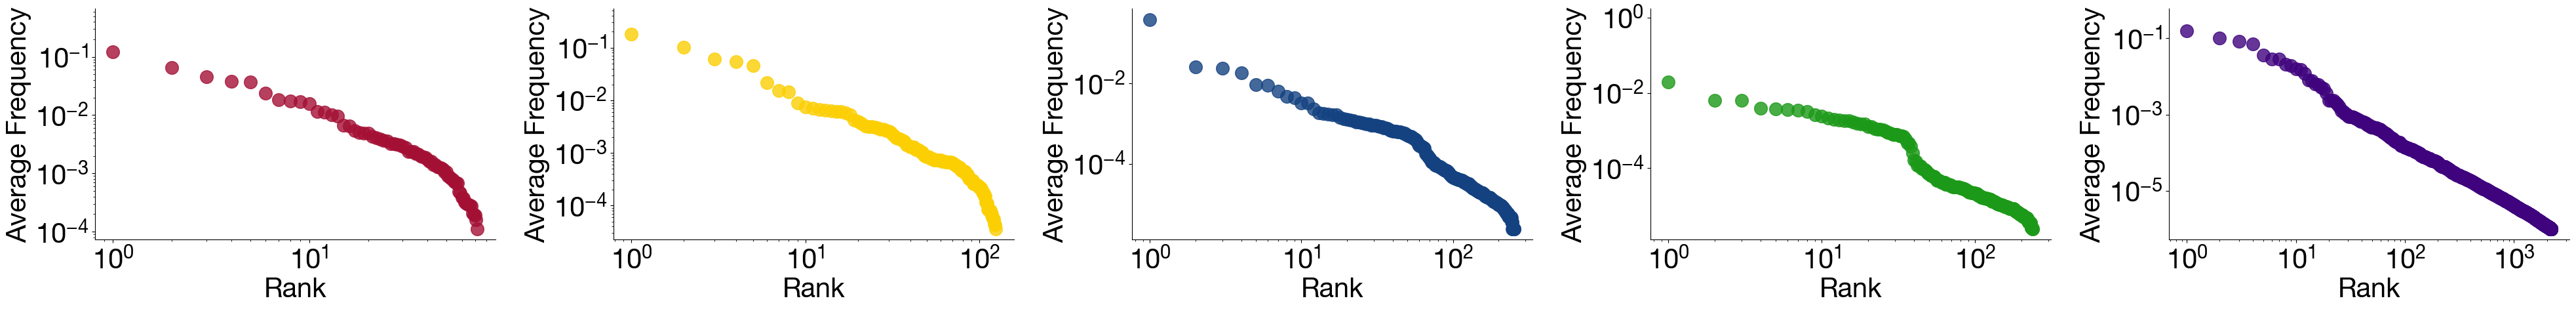

In [14]:
fig, axs = plt.subplots(1,5,figsize=(40,5.4))
plt.tight_layout()

## [Panel B] second row (frequency-rank plots)

x = np.arange(len(ypd_data['timeavg_freq']))
y = np.flip(np.sort(ypd_data['timeavg_freq']))
axs[0].scatter(x,y,alpha=0.8,s=200,c='#A41034')
axs[0].set_xlabel('Rank')
axs[0].set_ylabel('Average Frequency')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
# axs[0].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[0].spines[['right', 'top']].set_visible(False)

x = np.arange(len(ypa_data['timeavg_freq']))
y = np.flip(np.sort(ypa_data['timeavg_freq']))
axs[1].scatter(x,y,alpha=0.8,s=200,c='#fccf03')
axs[1].set_xlabel('Rank')
axs[1].set_ylabel('Average Frequency')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
# axs[1].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[1].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[1].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1].spines[['right', 'top']].set_visible(False)

x = np.arange(len(mnv_ab_data['timeavg_freq']))
y = np.flip(np.sort(mnv_ab_data['timeavg_freq']))
axs[2].scatter(x,y,alpha=0.8,s=200,c='#144281')
axs[2].set_xlabel('Rank')
axs[2].set_ylabel('Average Frequency')
axs[2].set_xscale('log')
axs[2].set_yscale('log')
# axs[0].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2].spines[['right', 'top']].set_visible(False)

x = np.arange(len(mnv_no_ab_data['timeavg_freq']))
y = np.flip(np.sort(mnv_no_ab_data['timeavg_freq']))
axs[3].scatter(x,y,alpha=0.8,s=200,c='#1C9918')
axs[3].set_xlabel('Rank')
axs[3].set_ylabel('Average Frequency')
axs[3].set_xscale('log')
axs[3].set_yscale('log')
# axs[1].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[1].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[1].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[3].spines[['right', 'top']].set_visible(False)

x = np.arange(len(covid_data['timeavg_freq']))
y = np.flip(np.sort(covid_data['timeavg_freq']))
axs[4].scatter(x,y,alpha=0.8,s=200,c='#3F037D')
axs[4].set_xlabel('Rank')
axs[4].set_ylabel('Average Frequency')
axs[4].set_xscale('log')
axs[4].set_yscale('log')
# axs[2].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[2].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[2].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[4].spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/exp_rank_freq.pdf')

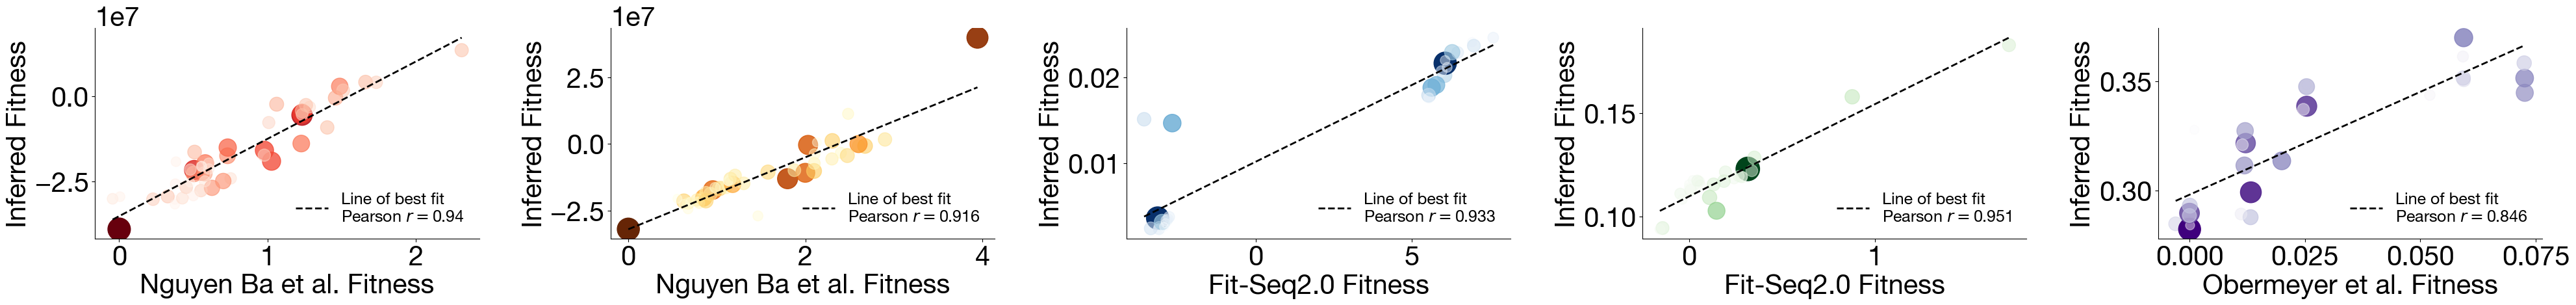

In [46]:
fig, axs = plt.subplots(1,5,figsize=(40,5.4))
plt.tight_layout()

rare_cutoff = 10**(-3)

## [Panel C] third row (high Average Frequency Cutoffs)

x = ypd_data['F_real'][ypd_data['timeavg_freq'] > rare_cutoff]
y = ypd_data['F_est'][ypd_data['timeavg_freq'] > rare_cutoff]
# axs[0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])
axs[0].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Reds')
# plt.xlim(3,5)
axs[0].set_xlabel('Nguyen Ba et al. Fitness')
axs[0].set_ylabel('Inferred Fitness')
# axs[0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[0].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[0].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[0].spines[['right', 'top']].set_visible(False)

x = ypa_data['F_real'][ypa_data['timeavg_freq'] > rare_cutoff]
y = ypa_data['F_est'][ypa_data['timeavg_freq'] > rare_cutoff]
# axs[1].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])
axs[1].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='YlOrBr')
# plt.xlim(3,5)
axs[1].set_xlabel('Nguyen Ba et al. Fitness')
axs[1].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1].spines[['right', 'top']].set_visible(False)

x = mnv_ab_data['F_real'][mnv_ab_data['timeavg_freq'] > rare_cutoff]
y = mnv_ab_data['F_est'][mnv_ab_data['timeavg_freq'] > rare_cutoff]
x_err = pd.read_csv('mnv_data/output_ab_FitSeq2_Result.csv')['Error_Fitness']
# axs[2].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])
axs[2].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Blues')

# plt.xlim(3,5)
axs[2].set_xlabel('Fit-Seq2.0 Fitness')
axs[2].set_ylabel('Inferred Fitness')
# axs[2].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2].spines[['right', 'top']].set_visible(False)

x = mnv_no_ab_data['F_real'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff]
y = mnv_no_ab_data['F_est'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff]
# axs[3].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])
axs[3].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Greens')
# plt.xlim(3,5)
axs[3].set_xlabel('Fit-Seq2.0 Fitness')
axs[3].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[3].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[3].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[3].spines[['right', 'top']].set_visible(False)


x = covid_data['F_real'][covid_data['timeavg_freq'] > rare_cutoff]
y = covid_data['F_est'][covid_data['timeavg_freq'] > rare_cutoff]
nanmask = ~np.isnan(x) & ~np.isnan(y)
x, y = x[nanmask], y[nanmask]

# axs[2].scatter(x,y,100,alpha=0.8, c='#144281')
temp = covid_data['timeavg_freq'][covid_data['timeavg_freq'] > rare_cutoff]
temp = temp[nanmask]
alphas=(2+np.log10(temp)-np.min(np.log10(temp)))/np.max((2+np.log10(temp)-np.min(np.log10(temp))))
marker_sizes = 200*(1+np.log10(temp)-np.min(np.log10(temp)))-100
colors = 100+np.log10(temp)
axs[4].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Purples')
# plt.xlim(3,5)
axs[4].set_xlabel('Obermeyer et al. Fitness')
axs[4].set_ylabel('Inferred Fitness')
# axs[2].set_ylim(-1.3,1.2)

pearson = scipy.stats.pearsonr(x, y)[0]


a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[4].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[4].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[4].spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/exp_high_cutoff.pdf')

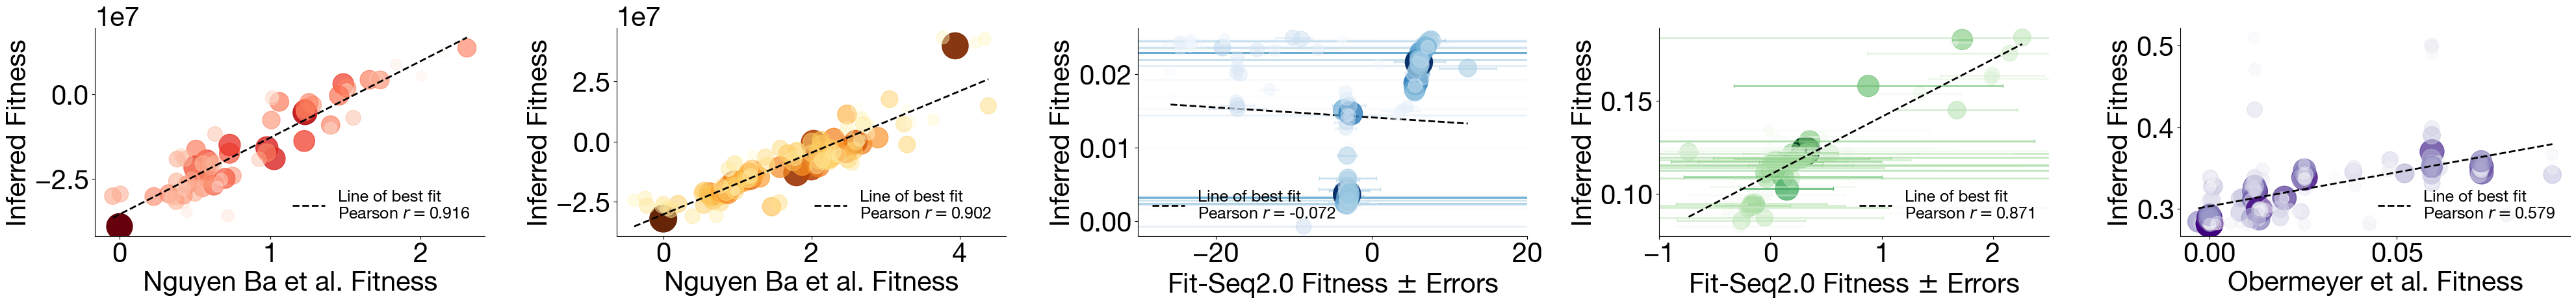

In [67]:
fig, axs = plt.subplots(1,5,figsize=(40,5.4))
plt.tight_layout()

rare_cutoff = 10**(-4.5)

## [Panel C] third row (high Average Frequency Cutoffs)

x = ypd_data['F_real'][ypd_data['timeavg_freq'] > rare_cutoff]
y = ypd_data['F_est'][ypd_data['timeavg_freq'] > rare_cutoff]
# axs[0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > rare_cutoff])
axs[0].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Reds')
# plt.xlim(3,5)
axs[0].set_xlabel('Nguyen Ba et al. Fitness')
axs[0].set_ylabel('Inferred Fitness')
# axs[0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[0].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[0].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[0].spines[['right', 'top']].set_visible(False)

x = ypa_data['F_real'][ypa_data['timeavg_freq'] > rare_cutoff]
y = ypa_data['F_est'][ypa_data['timeavg_freq'] > rare_cutoff]
# axs[1].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > rare_cutoff])
axs[1].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='YlOrBr')
# plt.xlim(3,5)
axs[1].set_xlabel('Nguyen Ba et al. Fitness')
axs[1].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1].spines[['right', 'top']].set_visible(False)

x = mnv_ab_data['F_real'][mnv_ab_data['timeavg_freq'] > rare_cutoff]
y = mnv_ab_data['F_est'][mnv_ab_data['timeavg_freq'] > rare_cutoff]
x_err = pd.read_csv('mnv_data/output_ab_FitSeq2_Result.csv')['Error_Fitness']
# axs[2].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(mnv_ab_data['timeavg_freq'][mnv_ab_data['timeavg_freq'] > rare_cutoff])
axs[2].scatter(x, y, s=marker_sizes, c=colors, alpha=alphas, cmap='Blues', zorder=3)
for i in range(len(x)):
    norm = plt.Normalize(vmin=colors.min(), vmax=colors.max())
    axs[2].errorbar(x[i], y[i],xerr=x_err[i],fmt='none',ecolor=plt.get_cmap('Blues')(norm(colors[i])), alpha=alphas[i],elinewidth=2,capsize=2)
axs[2].set_xlim(-30,20)



# plt.xlim(3,5)
axs[2].set_xlabel('Fit-Seq2.0 Fitness $\pm$ Errors')
axs[2].set_ylabel('Inferred Fitness')
# axs[2].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2].legend(loc="lower left", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2].spines[['right', 'top']].set_visible(False)

x = mnv_no_ab_data['F_real'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff]
y = mnv_no_ab_data['F_est'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff]
x_err = pd.read_csv('mnv_data/output_no_ab_FitSeq2_Result.csv')['Error_Fitness']
# axs[3].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(mnv_no_ab_data['timeavg_freq'][mnv_no_ab_data['timeavg_freq'] > rare_cutoff])
axs[3].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Greens')
for i in range(len(x)):
    norm = plt.Normalize(vmin=colors.min(), vmax=colors.max())
    axs[3].errorbar(x[i], y[i],xerr=x_err[i],fmt='none',ecolor=plt.get_cmap('Greens')(norm(colors[i])), alpha=alphas[i],elinewidth=2,capsize=2)
axs[3].set_xlim(-1,2.5)
# plt.xlim(3,5)
axs[3].set_xlabel('Fit-Seq2.0 Fitness $\pm$ Errors')
axs[3].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[3].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[3].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[3].spines[['right', 'top']].set_visible(False)


x = covid_data['F_real'][covid_data['timeavg_freq'] > rare_cutoff]
y = covid_data['F_est'][covid_data['timeavg_freq'] > rare_cutoff]
nanmask = ~np.isnan(x) & ~np.isnan(y)
x, y = x[nanmask], y[nanmask]

# axs[2].scatter(x,y,100,alpha=0.8, c='#144281')
temp = covid_data['timeavg_freq'][covid_data['timeavg_freq'] > rare_cutoff]
temp = temp[nanmask]
alphas=(2+np.log10(temp)-np.min(np.log10(temp)))/np.max((2+np.log10(temp)-np.min(np.log10(temp))))
marker_sizes = 200*(1+np.log10(temp)-np.min(np.log10(temp)))-100
colors = 100+np.log10(temp)
axs[4].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Purples')
# plt.xlim(3,5)
axs[4].set_xlabel('Obermeyer et al. Fitness')
axs[4].set_ylabel('Inferred Fitness')
# axs[2].set_ylim(-1.3,1.2)

pearson = scipy.stats.pearsonr(x, y)[0]


a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[4].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[4].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[4].spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/exp_low_cutoff.pdf')

# aggregated data

In [62]:
np.min(ypa_data['timeavg_freq'])

3.573675818181819e-05

## N = 1000, T = 1000

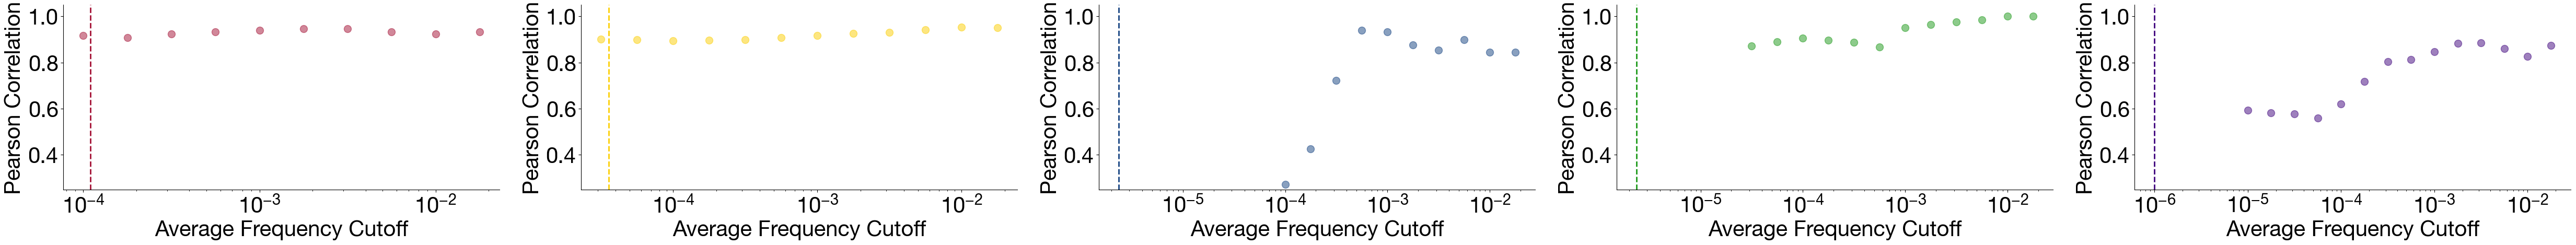

In [ ]:
cutoffs_to_keep = 14

fig, axs = plt.subplots(1,5,figsize=(50,5.4))
plt.tight_layout()

x = 10**ypd_data['correlation_data']['rare_cutoffs_log10'].to_numpy()[4:cutoffs_to_keep]
y = ypd_data['correlation_data']['pearson_values'].to_numpy()[4:cutoffs_to_keep]
axs[0].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#A41034')
axs[0].axvline(np.min(ypd_data['timeavg_freq']),linestyle='--',linewidth=2,c='#A41034')
axs[0].set_xlabel('Average Frequency Cutoff')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(0.25,1.05)

x = 10**ypa_data['correlation_data']['rare_cutoffs_log10'].to_numpy()[2:cutoffs_to_keep]
y = ypa_data['correlation_data']['pearson_values'].to_numpy()[2:cutoffs_to_keep]
axs[1].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#fccf03')
axs[1].axvline(np.min(ypa_data['timeavg_freq']),linestyle='--',linewidth=2,c='#fccf03')
axs[1].set_xlabel('Average Frequency Cutoff')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(0.25,1.05)

x = 10**mnv_ab_data['correlation_data']['rare_cutoffs_log10'].to_numpy()[4:cutoffs_to_keep]
y = mnv_ab_data['correlation_data']['pearson_values'].to_numpy()[4:cutoffs_to_keep]
axs[2].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#144281')
axs[2].axvline(np.min(mnv_ab_data['timeavg_freq']),linestyle='--',linewidth=2,c='#144281')
axs[2].set_xlabel('Average Frequency Cutoff')
axs[2].set_ylabel('Pearson Correlation')
axs[2].set_xscale('log')
axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_ylim(0.25,1.05)

x = 10**mnv_no_ab_data['correlation_data']['rare_cutoffs_log10'].to_numpy()[2:cutoffs_to_keep]
y = mnv_no_ab_data['correlation_data']['pearson_values'].to_numpy()[2:cutoffs_to_keep]
axs[3].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#1C9918')
axs[3].axvline(np.min(mnv_no_ab_data['timeavg_freq']),linestyle='--',linewidth=2,c='#1C9918')
axs[3].set_xlabel('Average Frequency Cutoff')
axs[3].set_ylabel('Pearson Correlation')
axs[3].set_xscale('log')
axs[3].spines[['right', 'top']].set_visible(False)
axs[3].set_ylim(0.25,1.05)


x = 10**covid_data['correlation_data']['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]
y = covid_data['correlation_data']['pearson_values'].to_numpy()[:cutoffs_to_keep]
axs[4].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#3F037D')
axs[4].axvline(np.min(covid_data['timeavg_freq']),linestyle='--',linewidth=2,c='#3F037D')
axs[4].set_xlabel('Average Frequency Cutoff')
axs[4].set_ylabel('Pearson Correlation')
axs[4].set_xscale('log')
axs[4].spines[['right', 'top']].set_visible(False)
axs[4].set_ylim(0.25,1.05)


# axs[0].legend(loc='lower right',fontsize=15)
# axs[1].legend(loc='lower right',fontsize=15)
# axs[2].legend(loc='lower right',fontsize=15)

plt.tight_layout()
plt.savefig('paper_plots/exp_pearson_N.pdf')

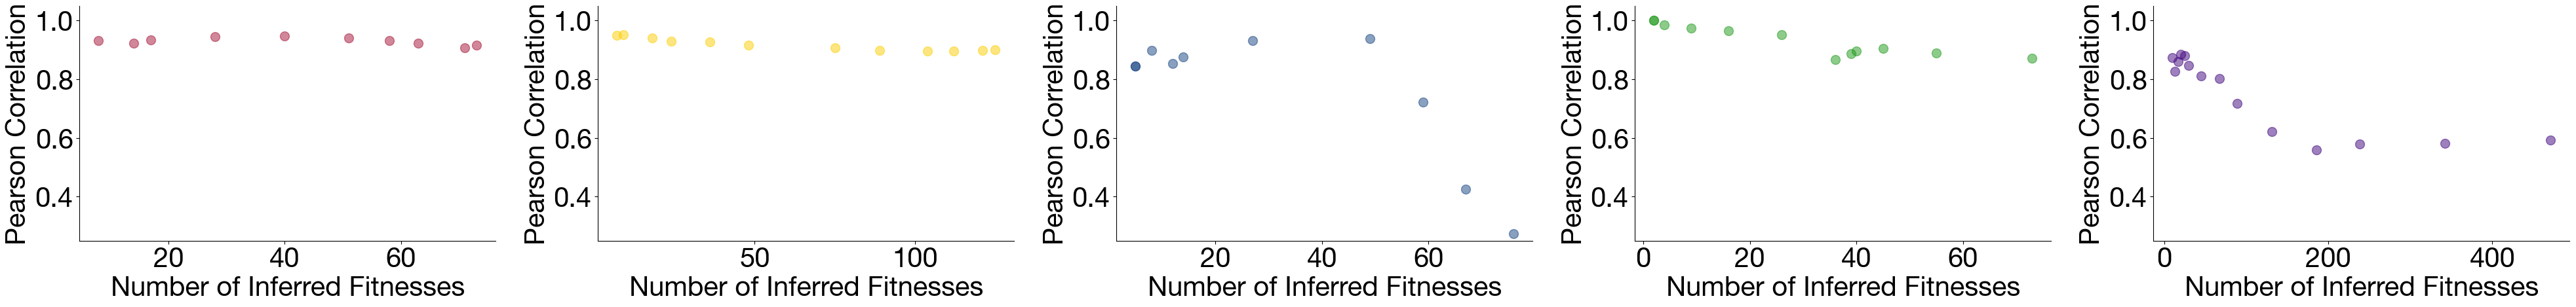

In [77]:
cutoffs_to_keep = 14

fig, axs = plt.subplots(1,5,figsize=(40,5.4))
plt.tight_layout()

x = ypd_data['correlation_data']['N_common_variants'].to_numpy()[4:cutoffs_to_keep]
y = ypd_data['correlation_data']['pearson_values'].to_numpy()[4:cutoffs_to_keep]
axs[0].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#A41034')
axs[0].set_xlabel('Number of Inferred Fitnesses')
axs[0].set_ylabel('Pearson Correlation')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(0.25,1.05)

x = ypa_data['correlation_data']['N_common_variants'].to_numpy()[2:cutoffs_to_keep]
y = ypa_data['correlation_data']['pearson_values'].to_numpy()[2:cutoffs_to_keep]
axs[1].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#fccf03')
axs[1].set_xlabel('Number of Inferred Fitnesses')
axs[1].set_ylabel('Pearson Correlation')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(0.25,1.05)

x = mnv_ab_data['correlation_data']['N_common_variants'].to_numpy()[4:cutoffs_to_keep]
y = mnv_ab_data['correlation_data']['pearson_values'].to_numpy()[4:cutoffs_to_keep]
axs[2].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#144281')
axs[2].set_xlabel('Number of Inferred Fitnesses')
axs[2].set_ylabel('Pearson Correlation')
axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_ylim(0.25,1.05)

x = mnv_no_ab_data['correlation_data']['N_common_variants'].to_numpy()[2:cutoffs_to_keep]
y = mnv_no_ab_data['correlation_data']['pearson_values'].to_numpy()[2:cutoffs_to_keep]
axs[3].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#1C9918')
axs[3].set_xlabel('Number of Inferred Fitnesses')
axs[3].set_ylabel('Pearson Correlation')
axs[3].spines[['right', 'top']].set_visible(False)
axs[3].set_ylim(0.25,1.05)

x = covid_data['correlation_data']['N_common_variants'].to_numpy()[:cutoffs_to_keep]
y = covid_data['correlation_data']['pearson_values'].to_numpy()[:cutoffs_to_keep]
axs[4].plot(x,y,marker='o',alpha=0.5,markersize=10,linestyle='',c='#3F037D')
axs[4].set_xlabel('Number of Inferred Fitnesses')
axs[4].set_ylabel('Pearson Correlation')
axs[4].spines[['right', 'top']].set_visible(False)
axs[4].set_ylim(0.25,1.05)

# axs[0].legend(loc='lower right',fontsize=15)
# axs[1].legend(loc='lower right',fontsize=15)
# axs[2].legend(loc='lower right',fontsize=15)

plt.tight_layout()
plt.savefig('paper_plots/exp_numpoints.pdf')

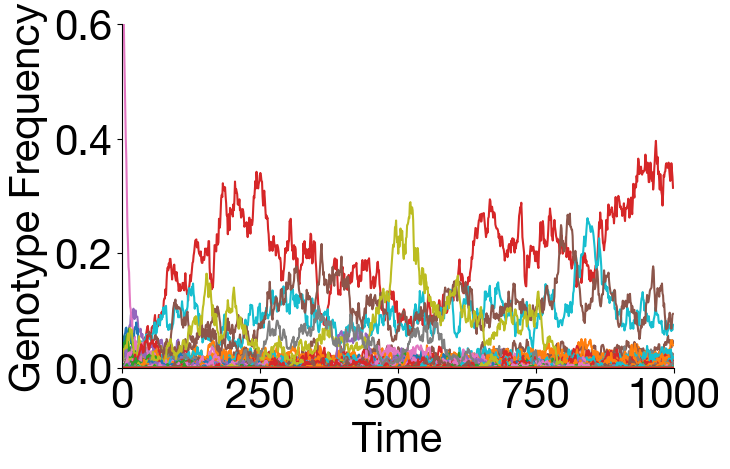

In [56]:
freq_timeseries = np.loadtxt('data/wrightfisher_freq_timeseries_L10_N1000_T1000_mu0.01_trial16.csv',delimiter=',')
sd_ts_schematic = freq_timeseries.T

fig, axs = plt.subplots(figsize=(8,5.4))
plt.plot(sd_ts_schematic)

plt.xlim(0,freq_timeseries.shape[1])
plt.ylim(0,0.6)
axs.spines[['right', 'top']].set_visible(False)
plt.xlabel('Time')
plt.ylabel('Genotype Frequency')
plt.tight_layout()
plt.savefig('paper_plots/stochastic.pdf')

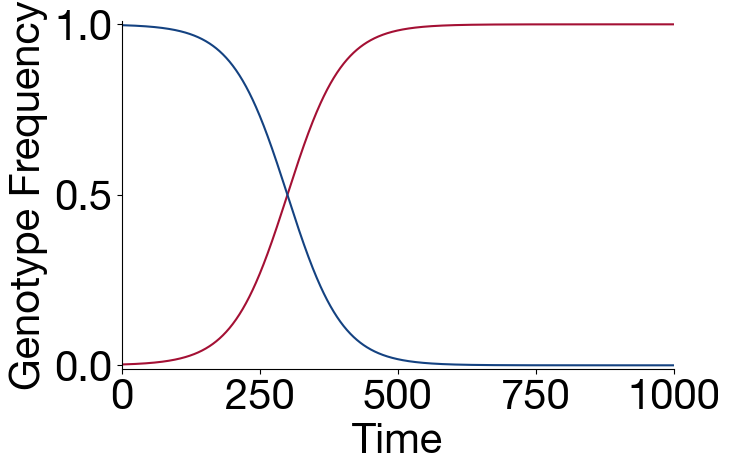

In [57]:
fig, axs = plt.subplots(figsize=(8,5.4))
xrange = np.arange(1000)
plt.plot(xrange,np.exp(0.02*(xrange-300))/(1+ np.exp(0.02*(xrange-300))),c='#A41034')
plt.plot(xrange,1 - np.exp(0.02*(xrange-300))/(1+ np.exp(0.02*(xrange-300))),c='#144281')
plt.xlim(0,1000)
plt.ylim(-0.01,1.01)
plt.xlabel('Time')
plt.ylabel('Genotype Frequency')
axs.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('paper_plots/logistic.pdf')